In [1]:
!pip install matplotlib seaborn

In [2]:
# Celda 1: Cargar librerías y datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

# Cargar el dataset maestro
df = pd.read_csv("dataset_tecnico_hackathon_prueba_4.csv")

# Inspección rápida
print("--- Información General del Dataset ---")
print(df.info())
print("\n--- Muestra de las primeras 3 filas ---")
display(df.head(3))

--- Información General del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   titulo          5000 non-null   str  
 1   texto           5000 non-null   str  
 2   categoria       5000 non-null   str  
 3   palabras_clave  5000 non-null   str  
dtypes: str(4)
memory usage: 156.4 KB
None

--- Muestra de las primeras 3 filas ---


,titulo,texto,categoria,palabras_clave
0,GeekNews Frontend Weekly Deep Dive - 2026-07-06,GeekNews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,frontend,"['GeekNews', '주간']"
1,"AWS Claude Apps Gateway, GCP Workbench VS Code...","AWS Claude Apps Gateway, GCP Workbench VS Code...",cloud,"['Workbench VS Code', ""AI Agent Benchmarks ..."
2,Kubernetes RBAC — Control Who Can Do What in Y...,Without RBAC properly configured: A develope...,cloud,[]


--- Conteo por Categoría ---
categoria
frontend       1250
cloud          1250
backend        1250
datascience    1250
Name: count, dtype: int64


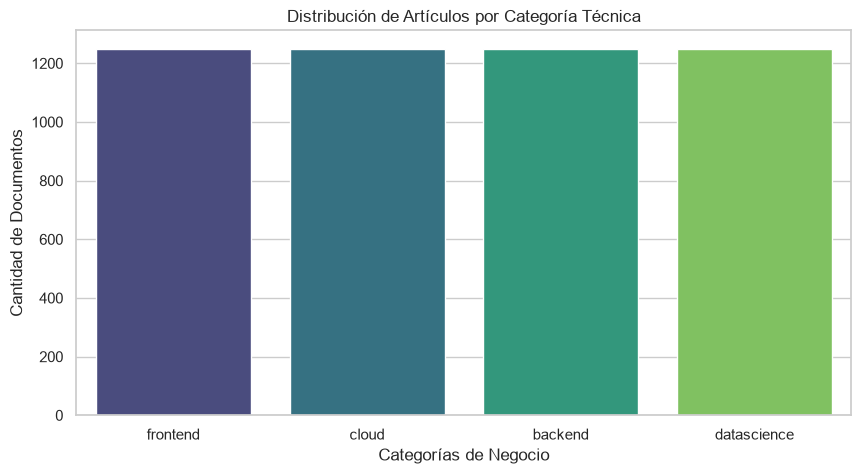

In [3]:
# Celda 2: Distribución de la variable objetivo
print("--- Conteo por Categoría ---")
print(df['categoria'].value_counts())

# Gráfico de barras para el reporte del Hackathon
sns.countplot(data=df, x='categoria', hue='categoria', palette='viridis', legend=False)
plt.title('Distribución de Artículos por Categoría Técnica')
plt.xlabel('Categorías de Negocio')
plt.ylabel('Cantidad de Documentos')
plt.show()

--- Estadísticas Descriptivas del Conteo de Palabras ---
count    5000.000000
mean       16.016200
std         4.701995
min         5.000000
25%        13.000000
50%        15.000000
75%        18.000000
max        55.000000
Name: conteo_palabras, dtype: float64


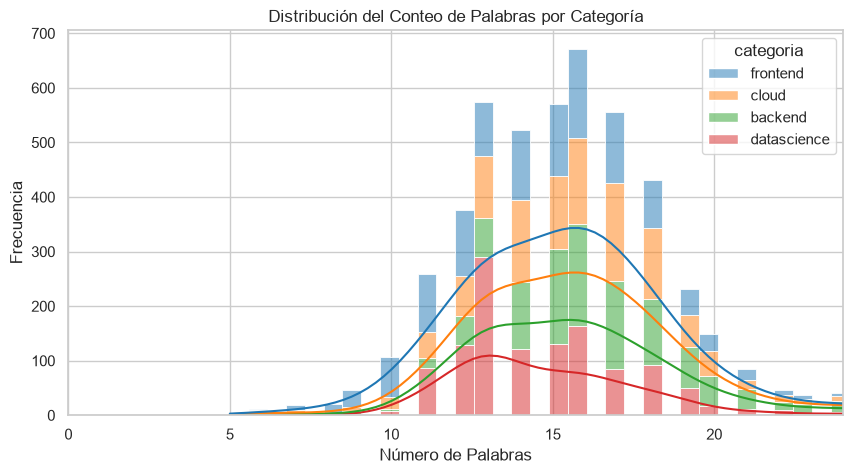

In [4]:
# Celda 3: Estadísticas de longitud
# Calculamos la cantidad de palabras por texto
df['conteo_palabras'] = df['texto'].apply(lambda x: len(str(x).split()))

print("--- Estadísticas Descriptivas del Conteo de Palabras ---")
print(df['conteo_palabras'].describe())

# Histograma de distribución
sns.histplot(data=df, x='conteo_palabras', hue='categoria', kde=True, multiple='stack', palette='tab10')
plt.title('Distribución del Conteo de Palabras por Categoría')
plt.xlabel('Número de Palabras')
plt.ylabel('Frecuencia')
plt.xlim(0, df['conteo_palabras'].quantile(0.95)) # Evita que los outliers arruinen la escala visual
plt.show()

In [5]:
# Celda 4: Palabras más comunes antes del preprocesamiento profundo
def obtener_palabras_comunes(texto_columna, top_n=15):
    todas_las_palabras = " ".join(texto_columna.astype(str)).lower().split()
    conteo = Counter(todas_las_palabras)
    return conteo.most_common(top_n)

print("--- Top 15 palabras más comunes en el Dataset Completo ---")
for palabra, frec in obtener_palabras_comunes(df['texto']):
    print(f"{palabra}: {frec}")

--- Top 15 palabras más comunes en el Dataset Completo ---
a: 2789
the: 2260
and: 1526
is: 1278
to: 1102
in: 972
of: 965
with: 778
for: 752
your: 750
you: 591
i: 584
that: 506
pipeline: 416
how: 415


In [7]:
# Celda 5: Pipeline de Preprocesamiento y Lematización con spaCy
import pandas as pd
import spacy

# 1. Cargar el modelo en inglés validado en el EDA
# Asegúrate de haber ejecutado: !python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"]) 
# Deshabilitamos el 'ner' y el 'parser' en esta celda para que el proceso sea 10 veces más rápido, 
# ya que aquí solo nos interesa limpiar y lematizar el texto.

# 2. Cargar nuestro dataset generado
df = pd.read_csv("dataset_tecnico_hackathon_prueba_4.csv")

# 3. Definición de la función limpiadora
def limpiar_y_lematizar(texto):
    """
    Limpia el texto convirtiéndolo a minúsculas, eliminando stop words,
    signos de puntuación y aplicando lematización a las palabras restantes.
    """
    if not isinstance(texto, str):
        return ""
    
    # Procesar el texto a través del pipeline de spaCy
    doc = nlp(texto.lower())
    
    # Filtrar tokens y extraer sus lemas (raíces)
    tokens_limpios = [
        token.lemma_ # Extrae la raíz de la palabra (ej: building -> build, instances -> instance)
        for token in doc 
        if not token.is_stop      # Elimina "the", "and", "is", "to", etc.
        and not token.is_punct    # Elimina puntos, comas, signos de interrogación
        and not token.is_space    # Elimina espacios en blanco o saltos de línea extras
        and len(token.text) > 2   # Elimina palabras residuales de 1 o 2 letras que suelen ser ruido
    ]
    
    # Volver a unir los lemas en una sola cadena de texto separada por espacios
    return " ".join(tokens_limpios)

# 4. Aplicar el preprocesamiento a todo el Dataset
print("⏳ Iniciando la lematización del dataset (esto puede tomar un par de minutos)...")
df['texto_limpio'] = df['texto'].apply(limpiar_y_lematizar)
print("✅ ¡Preprocesamiento completado con éxito!")

# 5. Guardar el progreso en un nuevo CSV para el paso de modelado del Día 4
df.to_csv("dataset_tecnico_preprocesado.csv", index=False, encoding="utf-8")
print("💾 Archivo 'dataset_tecnico_preprocesado.csv' guardado.")

⏳ Iniciando la lematización del dataset (esto puede tomar un par de minutos)...
✅ ¡Preprocesamiento completado con éxito!
💾 Archivo 'dataset_tecnico_preprocesado.csv' guardado.


In [9]:
# Celda 6: Comparación del texto original vs texto limpio
print("=== TEXTO ORIGINAL ===")
print(df['texto'].iloc[5])

print("\n=== TEXTO LIMPIO Y LEMATIZADO ===")
print(df['texto_limpio'].iloc[5])

=== TEXTO ORIGINAL ===
Starting a new career in unfamiliar territory can feel overwhelming.  You constantly worry about...

=== TEXTO LIMPIO Y LEMATIZADO ===
start new career unfamiliar territory feel overwhelming constantly worry
